# CREDIT CARD DEFAULT PREDICTION

Machine Learning Classification Project

# 1. Business Problem

The goal of this project is to build a machine learning model capable of predicting whether a customer will default on their credit card payment next month.

This type of solution can support:
- credit risk analysis,
- banking decision systems,
- customer risk profiling,
- financial loss reduction.

The project focuses on binary classification:

- `0` → customer will repay the credit card,
- `1` → customer will default.

# 2. Dataset Information

Dataset used:

```text
default_of_credit_card_clients.xls
```

The dataset contains:

demographic information,
repayment history,
bill statement history,
previous payment history.

Target variable:

```text
default
```

## 3. Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)

from sklearn.ensemble import RandomForestClassifier

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

# 4. Load Dataset and Initial Exploration

The dataset was loaded using Pandas.

Initial exploration included:
- dataset structure,
- feature types,
- statistical summary,
- dataset dimensions.

In [2]:
dataset = pd.read_excel('default_of_credit_card_clients.xls', header=1)

dataset.info()
dataset.describe()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


# 5. Remove Unnecessary Column and Rename Target Variable

The `ID` column was removed because it does not provide predictive information.

The target column was renamed for easier analysis.

In [3]:
dataset.rename(columns={'default payment next month': 'default'}, inplace=True)

dataset.drop(columns='ID', inplace=True)

# 6. Missing Values Analysis

The dataset was checked for missing values.

No missing values were detected, therefore no imputation techniques were required.

In [4]:
dataset.isnull().mean() * 100

LIMIT_BAL    0.0
SEX          0.0
EDUCATION    0.0
MARRIAGE     0.0
AGE          0.0
PAY_0        0.0
PAY_2        0.0
PAY_3        0.0
PAY_4        0.0
PAY_5        0.0
PAY_6        0.0
BILL_AMT1    0.0
BILL_AMT2    0.0
BILL_AMT3    0.0
BILL_AMT4    0.0
BILL_AMT5    0.0
BILL_AMT6    0.0
PAY_AMT1     0.0
PAY_AMT2     0.0
PAY_AMT3     0.0
PAY_AMT4     0.0
PAY_AMT5     0.0
PAY_AMT6     0.0
default      0.0
dtype: float64

# 7. Duplicated Values Analysis

After removing the `ID` column,
35 duplicated observations were detected.

These observations were retained because:
- the original dataset contained unique IDs,
- similar customer profiles may naturally occur in real financial data.

In [5]:
dataset.duplicated().sum()

np.int64(35)

# 8. Incorrect Values Analysis — EDUCATION

The `EDUCATION` variable contained unexpected categories:
- 0
- 5
- 6

According to the dataset documentation, these values were grouped into category: others

In [6]:
dataset['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [7]:
dataset['EDUCATION'] = dataset['EDUCATION'].replace([0, 5, 6], 4)

dataset['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64

# 9. Incorrect Values Analysis — MARRIAGE

The `MARRIAGE` variable contained category `0`, which was regroup to: others

In [8]:
dataset['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [9]:
dataset['MARRIAGE'] = dataset['MARRIAGE'].replace(0, 3)

dataset['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64

# 10. Target Variable Distribution

The dataset is imbalanced:
- most customers repay their credit cards,
- fewer customers default.

To reduce imbalance impact,
`class_weight='balanced'`
was used in the Random Forest model.

In [10]:
dataset['default'].value_counts()

default
0    23364
1     6636
Name: count, dtype: int64

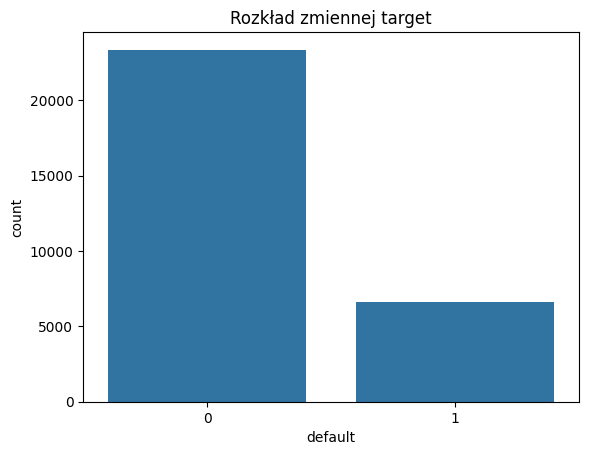

In [11]:
sns.countplot(x='default', data=dataset)

plt.title('Distribution of the target variable')
plt.show()

# 11. Correlation Analysis

Correlation analysis revealed
strong relationships between:
- payment history variables,
- bill amount variables,
- previous payment variables.

Random Forest handles correlated features effectively,
therefore correlated variables were retained.

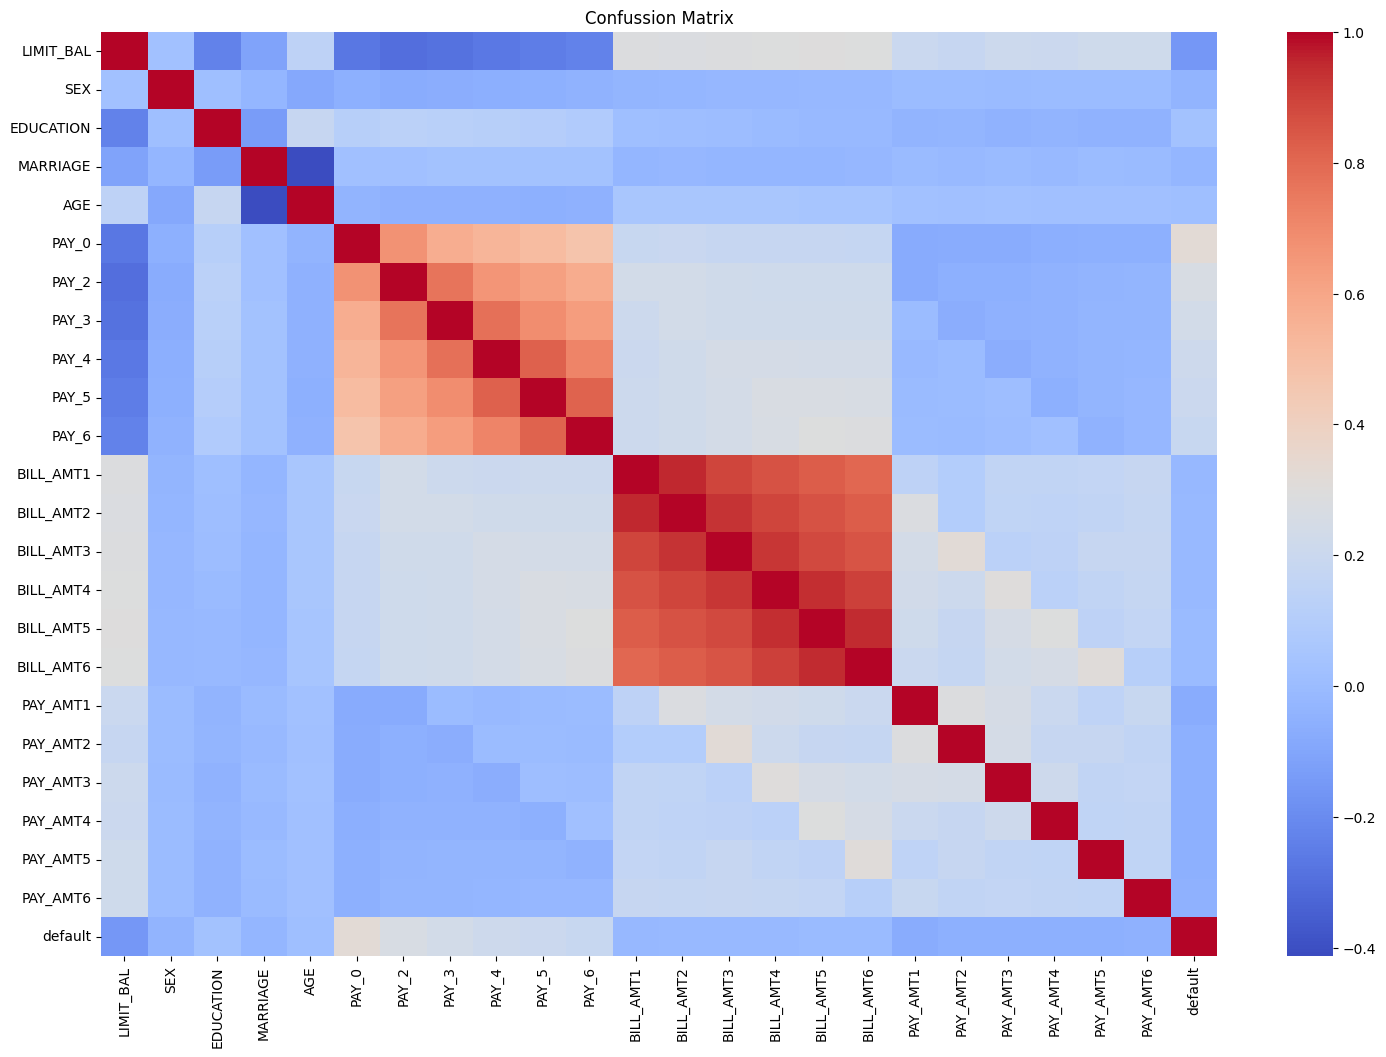

In [12]:
plt.figure(figsize=(18, 12))

sns.heatmap(
    dataset.corr(),
    cmap='coolwarm'
)

plt.title('Confussion Matrix')
plt.show()

# 12. Numerical Features Distribution

Distribution plots and boxplots were used
to analyze:
- skewness,
- outliers,
- variable distributions.

Several variables contained strong skewness and outliers

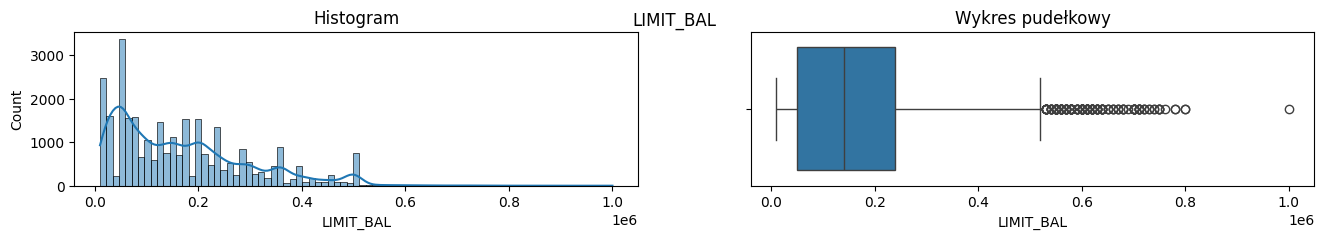

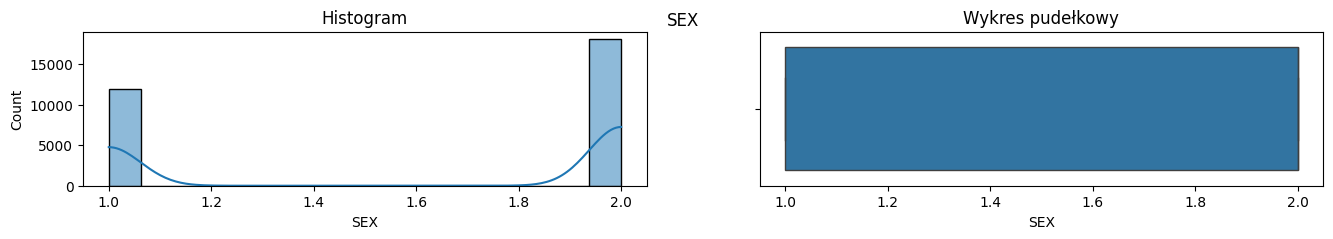

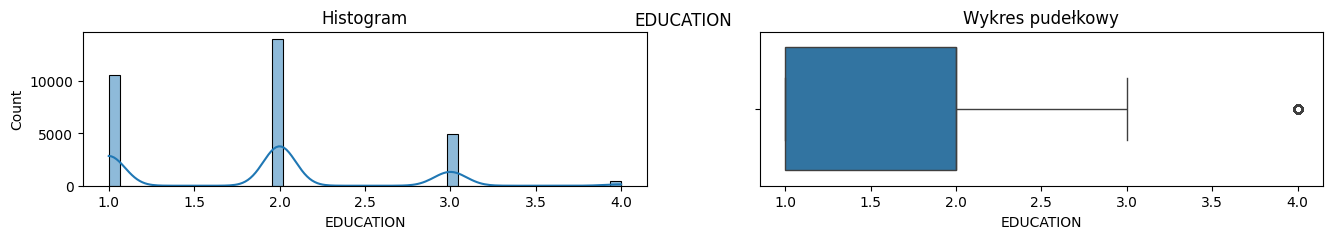

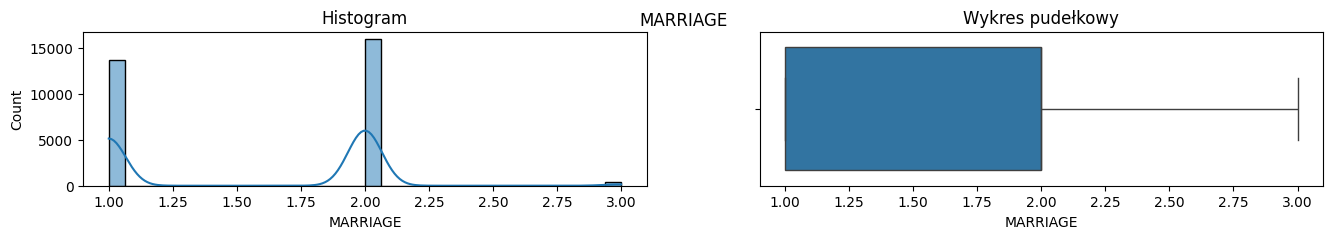

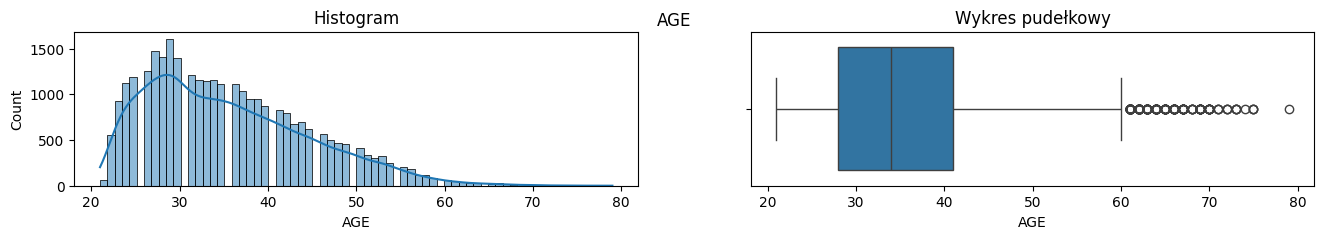

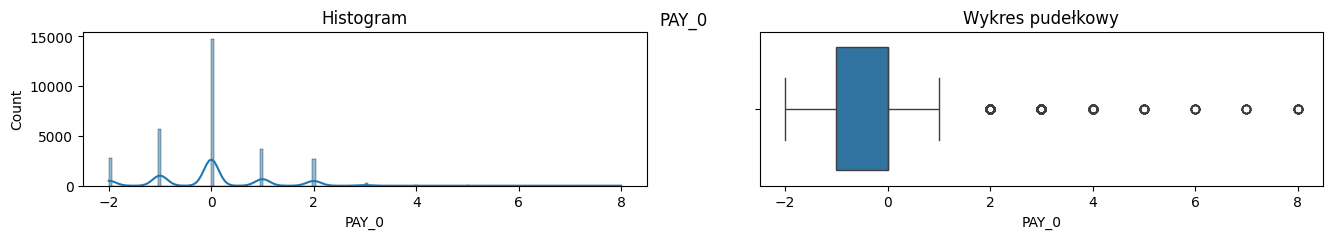

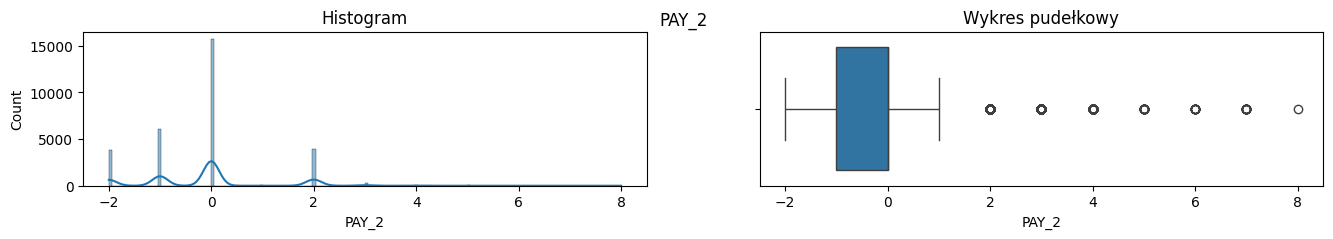

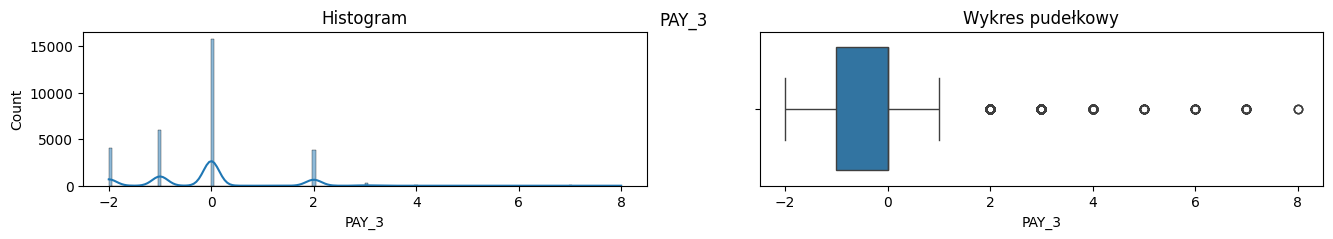

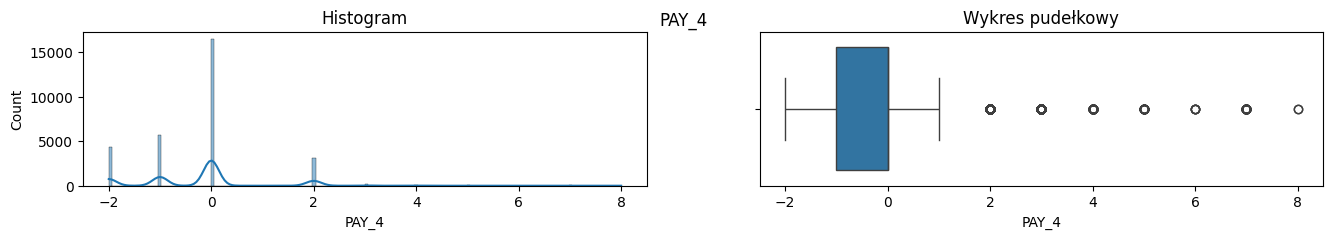

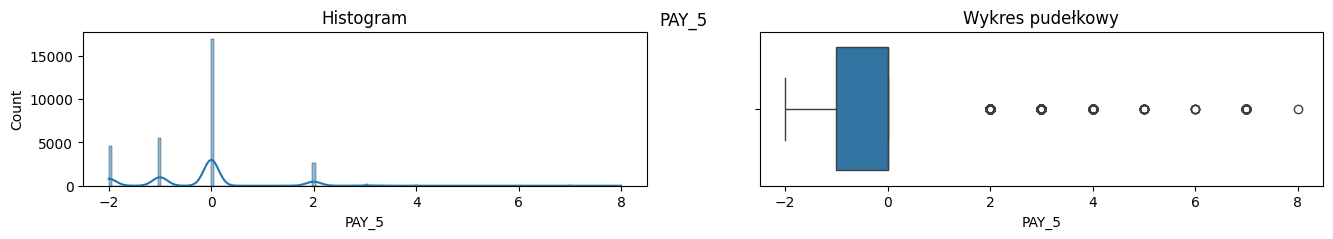

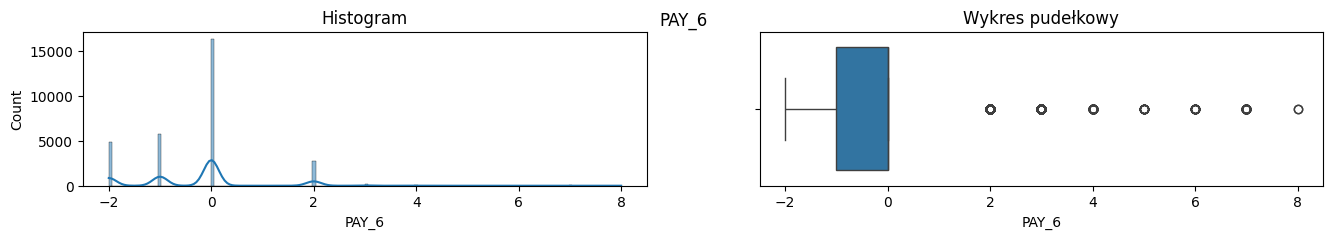

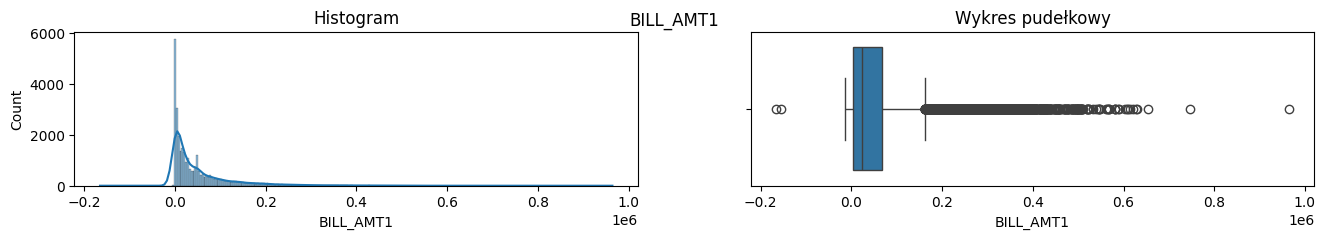

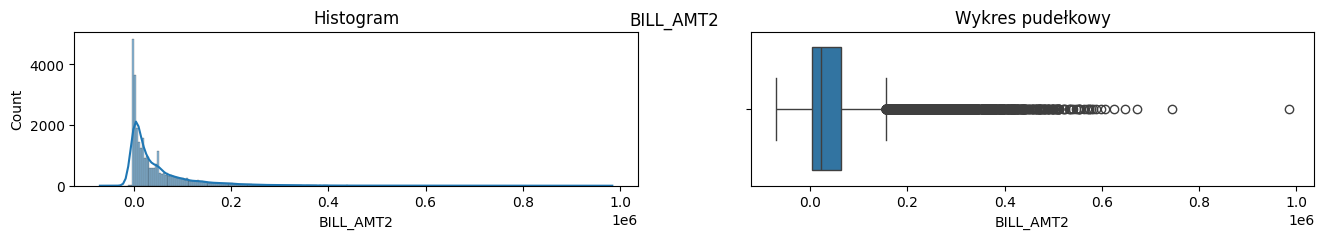

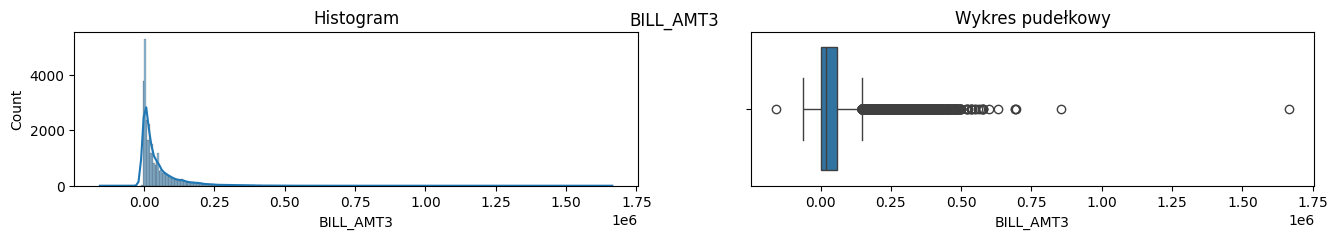

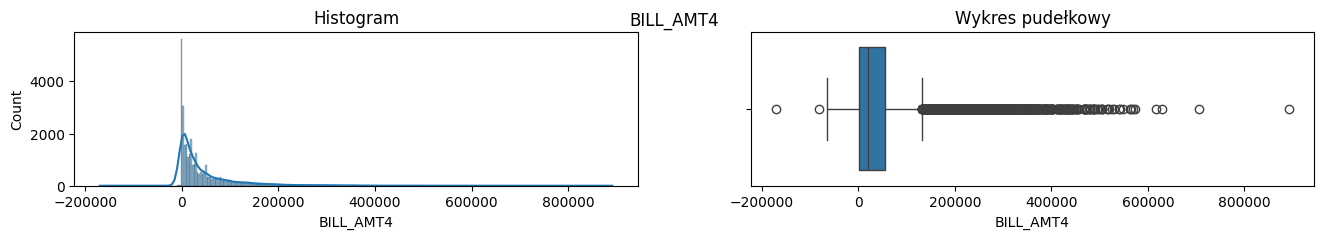

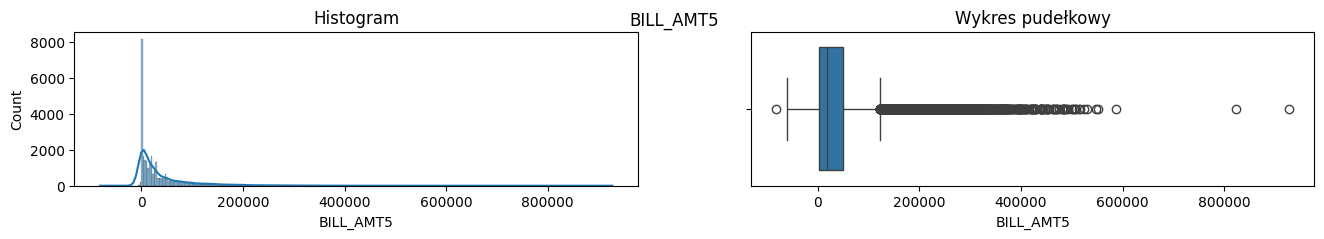

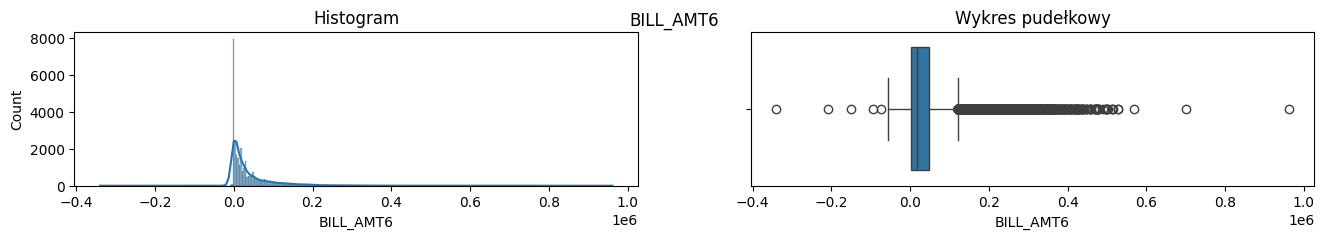

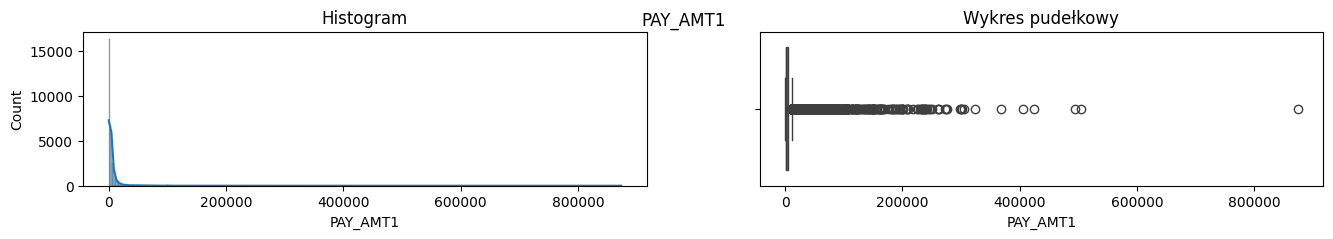

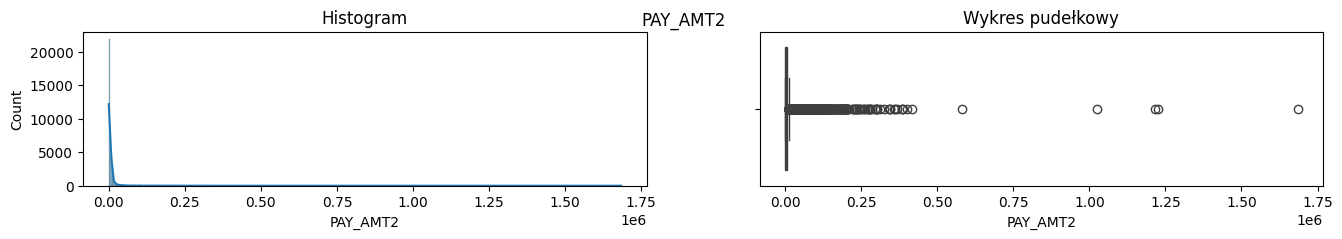

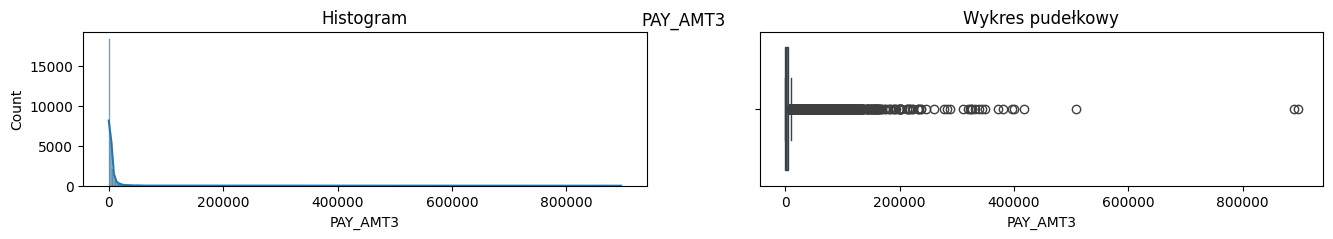

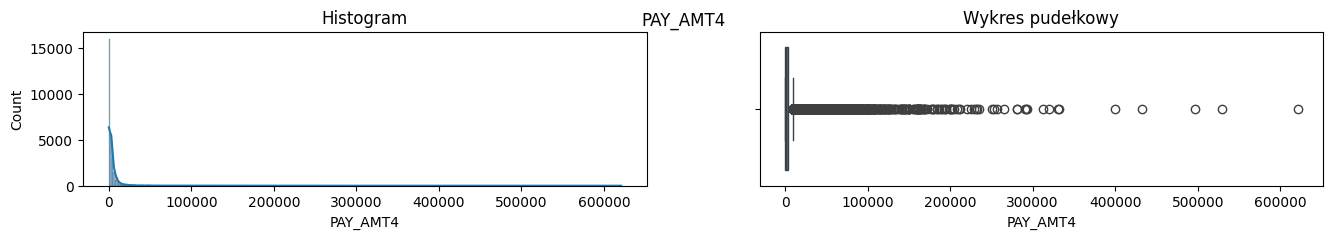

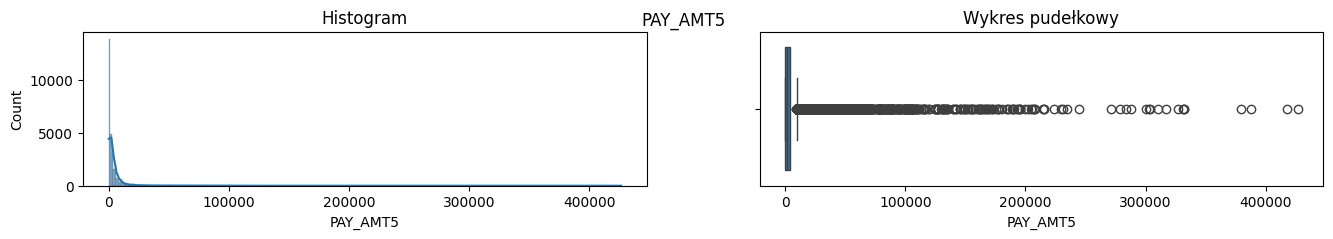

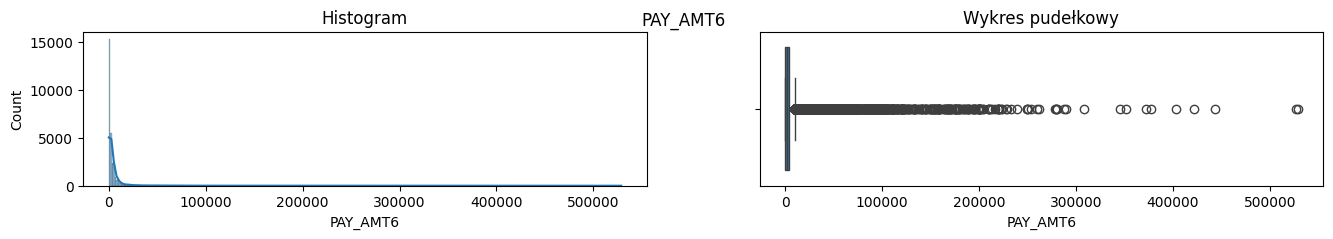

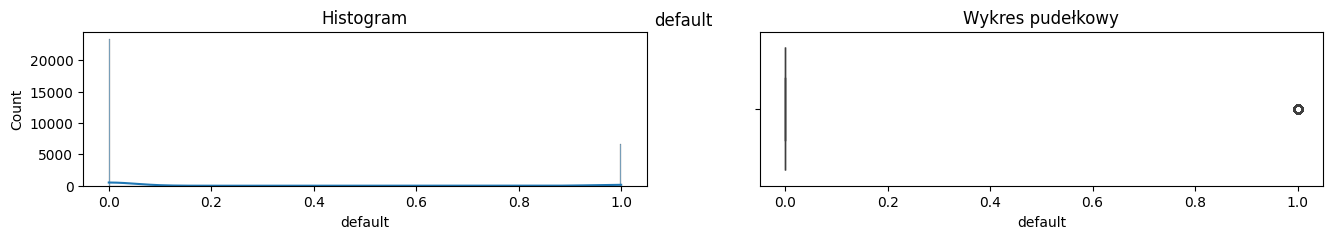

In [13]:
for variable in dataset.select_dtypes(include=np.number).columns:

    fig = plt.figure(figsize=(16, 2))
    fig.suptitle(variable, fontsize=12)
    
    plt.subplot(1, 2, 1)
    sns.histplot(dataset[variable], kde=True)
    plt.title('Histogram')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=dataset[variable])
    plt.title('Wykres pudełkowy')
    plt.show()

# 13. Split Features and Target Variable

The dataset was divided into:
- features (`X`)
- target variable (`y`)

In [14]:
X = dataset.drop(columns=['default'])

y = dataset['default']

# 14. Train Test Split

The dataset was split into:
- training data,
- testing data.

Stratification was applied
to preserve the original target distribution.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 15. Feature Types

Features were divided into:
- numerical variables,
- categorical variables.

In [16]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

numeric_features = [
    col for col in numeric_features
    if col not in categorical_features
]

# 16. Preprocessing Pipeline

A preprocessing pipeline was created using:
- ColumnTransformer
- OneHotEncoder

Numerical features were passed without scaling,
because Random Forest does not require feature standardization.

In [17]:
numeric_transformer = 'passthrough'

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(

    transformers=[

        ('num', 'passthrough', numeric_features),

        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_features)

    ]
)

# 17. Random Forest Model

Random Forest was selected because:
- it performs well on tabular data,
- it handles correlated variables effectively,
- it is resistant to overfitting,
- it provides feature importance analysis.

In [18]:
model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))

])

# 18. Hyperparameter Tuning

GridSearchCV was used
to optimize Random Forest hyperparameters.

In [19]:
params = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=params,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# 19. Model Training

The model was trained
using the training dataset
and optimized hyperparameters.

In [20]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [10, 20, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messa

# 20. Best Hyperparameters

The following hyperparameters
produced the best model performance.

In [21]:
grid_search.best_params_

{'classifier__max_depth': 10,
 'classifier__max_features': 'log2',
 'classifier__min_samples_leaf': 4,
 'classifier__min_samples_split': 10,
 'classifier__n_estimators': 200}

# 21. Model Evaluation Function

A custom evaluation function was created
to calculate:
- classification report,
- confusion matrix,
- ROC curve,
- F1-score,
- ROC-AUC.

In [22]:
metrics_dataframe = pd.DataFrame(columns = ['Model', 'F1_score', 'AUC'])
metrics_dataframe
models = []
models_names = []
predictions_proba_list = []
def calculate_metrics(model, name, X_checked, y_checked):
    models.append(model)
    models_names.append(name)
    global metrics_dataframe
    predictions = model.predict(X_checked)
    predictions_proba = model.predict_proba(X_checked)
    predictions_proba_list.append(predictions_proba[:,1])

    print(classification_report(y_checked, predictions))

    plt.figure()
    cm = confusion_matrix(y_checked, predictions)
    ax = sns.heatmap(cm, annot=True, cmap='Blues', fmt='.0f')
    ax.set_title('Confusion Matrix\n\n')
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values ')
    plt.show()

    fig = plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], 'k--')
    for model_selected, name_selected, pred_proba in zip(models, models_names, predictions_proba_list):
        fpr, tpr, thresholds = roc_curve(y_checked, pred_proba)
        plt.plot(fpr, tpr, label=name_selected)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    f1_metric = f1_score(y_checked, predictions)
    auc_metric = roc_auc_score(y_checked, predictions_proba[:,1])
    
    metrics_dataframe.loc[len(metrics_dataframe)] = [
        name,
        f1_metric,
        auc_metric
    ]
    
    return metrics_dataframe

# 22. Final Model Evaluation

The final Random Forest model
was evaluated on the test dataset.

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.51      0.58      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.80      0.79      0.79      6000



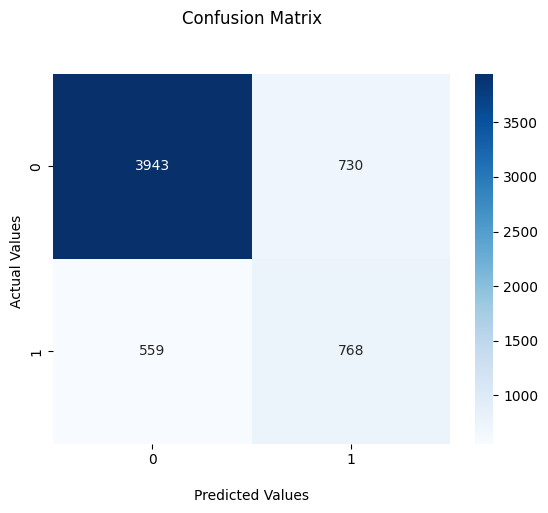

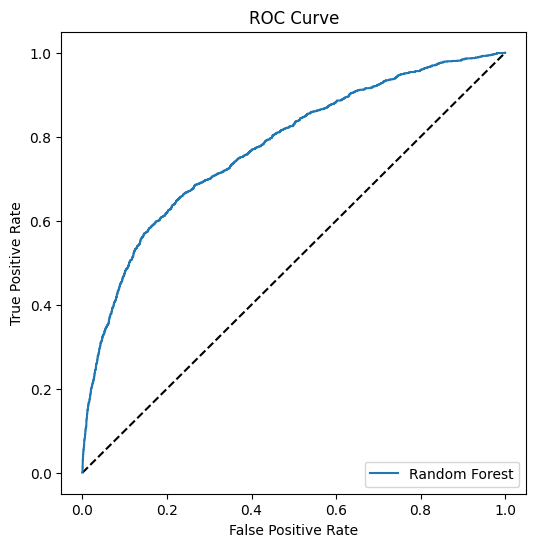

,Model,F1_score,AUC
0,Random Forest,0.543717,0.773883


In [23]:
calculate_metrics(grid_search.best_estimator_, 'Random Forest', X_test, y_test)

# 23. Feature Importance Analysis

Feature importance analysis
was performed to identify
the variables with the greatest impact
on customer default prediction.

In [24]:
best_model = grid_search.best_estimator_

encoded_cat_features = list(

    best_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_features)
)

feature_names = (numeric_features + encoded_cat_features)

importances = (best_model.named_steps['classifier'].feature_importances_)

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

importance_df = importance_df.sort_values(by='importance', ascending=False)

# 24. Feature Importance Visualization

The chart below presents
the 15 most important features
used by the Random Forest model.

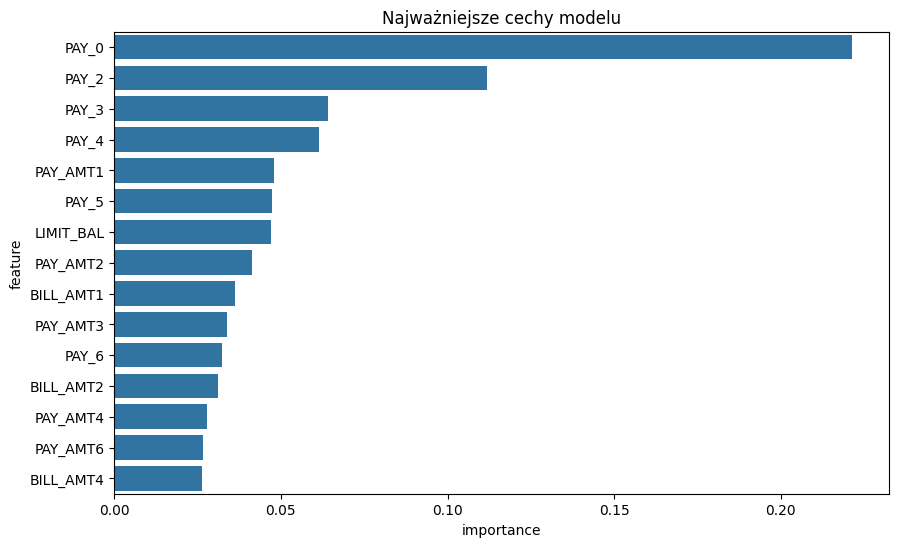

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(15),
    x='importance',
    y='feature'
)

plt.title('Najważniejsze cechy modelu')

plt.show()

# 26. Final Conclusions

The project demonstrated that repayment history variables
were the strongest predictors of customer default risk.

Random Forest achieved balanced classification performance
while handling correlated numerical features effectively.

Final model performance:
- F1-score: 0.54
- ROC-AUC: 0.77

Feature importance analysis showed
that recent payment delays
had the greatest influence on predictions.

The project demonstrates
a complete machine learning workflow:
- data cleaning,
- exploratory data analysis,
- preprocessing,
- model training,
- hyperparameter tuning,
- model evaluation,
- model interpretation.